In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
FISH_ATTRS = 3


In [3]:
def get_angles(x,y) -> np.typing.NDArray :
    '''returns the angle of a given pos'''

    x = np.array(x)
    y = np.array(y)

    theta = np.arctan2(x,y)

    theta %= np.pi*2

    return theta

In [4]:
def find_turning_points(x:np.typing.NDArray,y:np.typing.NDArray) -> list[tuple[int,int]] :

    '''
    find turning points in the movements of a fish , 
    given its x and y coords , will return a list of
    timestamps of detections of turnarounds.
    '''

    theta = np.arctan2(x,y)  #angle with horizontal 
    theta %= np.pi*2

    raw_diff = theta[1:] - theta[:-1]

    # find places where the diff is more than 180 degrees 
    # as that means that there was a wrap around 

    mod_diff = raw_diff % np.pi 

    mod_p1_diff = mod_diff - np.pi # incase the diff is in the other direction i.e 179 instead of -1 deg

    diff = np.array([

        v if abs(mod_p1_diff[i]) > v else mod_p1_diff[i]
        for i,v in enumerate(mod_diff)

    ])

    turn_arounds = []
    for start in np.where(np.diff(np.sign(diff)))[0] :
        turn_arounds.append((start,start+1))

    return turn_arounds

In [5]:
#calculating e=v/mod v
def get_unit_vectors(data_chunk) -> list[np.ndarray]:
    vectors = []
    for fish_i in range(0, data_chunk.shape[1], FISH_ATTRS):
        x = data_chunk.iloc[:, fish_i].values
        y = data_chunk.iloc[:, fish_i + 1].values

        #velocity from finite differences (displacement per frame)
        vx = np.diff(x)
        vy = np.diff(y)

        #|v| — speed at each frame
        speed = np.sqrt(vx**2 + vy**2)

        #avoid division by zero when fish is stationary
        speed[speed == 0] = np.nan

        #e_i = v / |v|
        ex = vx / speed
        ey = vy / speed

        vectors.append(np.column_stack((ex, ey)))

    return vectors


In [6]:
def Hij(ei: np.ndarray, ej: np.ndarray, tau_frames: int) -> np.ndarray:
    '''
    H_ij(t, tau) = e_i(t) . e_j(t - tau)
    '''
    T = ei.shape[0]
    #e_i(t) . e_j(t - tau) for all t
    return np.einsum('ti,ti->t', ei[tau_frames:], ej[:T - tau_frames])

In [7]:
#w needs to be changed depending on noise of the data, could use value luca gave?
def Cij(ei: np.ndarray, ej: np.ndarray, tau_frames: int, w: int = 2) -> np.ndarray:
    
    #C_ij(t, tau, w) = 1/(2w+1) * sum_{k=-w}^{w} H_ij(t + k, tau)
    #Smoothed version of H_ij over (2w+1) frames.
    
    h      = Hij(ei, ej, tau_frames)
    window = 2 * w + 1

    if len(h) < window:
        return np.array([])

    cs = np.concatenate(([0], np.cumsum(h)))
    return (cs[window:] - cs[:-window]) / window

In [8]:
#ploarization
def polarisation(vectors: list[np.ndarray]) -> np.ndarray:
    N = len(vectors)
    summed = np.sum(vectors, axis=0)  #sum unit vectors across fish
    return np.linalg.norm(summed, axis=1) / N 

In [15]:
FPS = 50
DT = 1 / FPS

# def compute_Cij_matrix(ei: np.ndarray, ej: np.ndarray, tau_max_s: float = 2.0, w: int = 2):
#     tau_range = np.arange(2, int(tau_max_s * FPS) + 1)
#     C_rows = [Cij(ei, ej, tau, w) for tau in tau_range]
#     min_len = min(len(r) for r in C_rows)
#     C_matrix = np.array([r[:min_len] for r in C_rows])
#     return C_matrix, tau_range * DT

def compute_Cij_matrix(ei: np.ndarray, ej: np.ndarray, tau_max_s: float = 2.0, w: int = 2):
    # remove frames where either vector has NaN
    valid = ~(np.isnan(ei).any(axis=1) | np.isnan(ej).any(axis=1))
    ei = ei[valid]
    ej = ej[valid]
    
    tau_range = np.arange(2, int(tau_max_s * FPS) + 1)
    C_rows = [Cij(ei, ej, tau, w) for tau in tau_range]
    min_len = min(len(r) for r in C_rows)
    C_matrix = np.array([r[:min_len] for r in C_rows])
    return C_matrix, tau_range * DT

In [10]:
def plot_heatmap(C: np.ndarray, taus_s: np.ndarray, fish_i: int, fish_j: int, ax: plt.Axes = None):
    n_time = C.shape[1]
    t_axis = np.arange(n_time) * DT
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(C, aspect='auto', origin='lower',
                   extent=[t_axis[0], t_axis[-1], taus_s[0], taus_s[-1]],
                   vmin=-1, vmax=1, cmap='RdYlGn')
    best_tau = taus_s[int(np.argmax(C.mean(axis=1)))]
    ax.axhline(best_tau, color='blue', linewidth=1.2, linestyle='--', label=f'tau* = {best_tau:.2f}s')
    plt.colorbar(im, ax=ax, label='C_ij')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Delay tau (s)')
    ax.set_title(f'Fish {fish_i + 1} copying Fish {fish_j + 1}  (tau* = {best_tau:.2f}s)')
    ax.legend(fontsize=8)
    return ax

turns found: 132


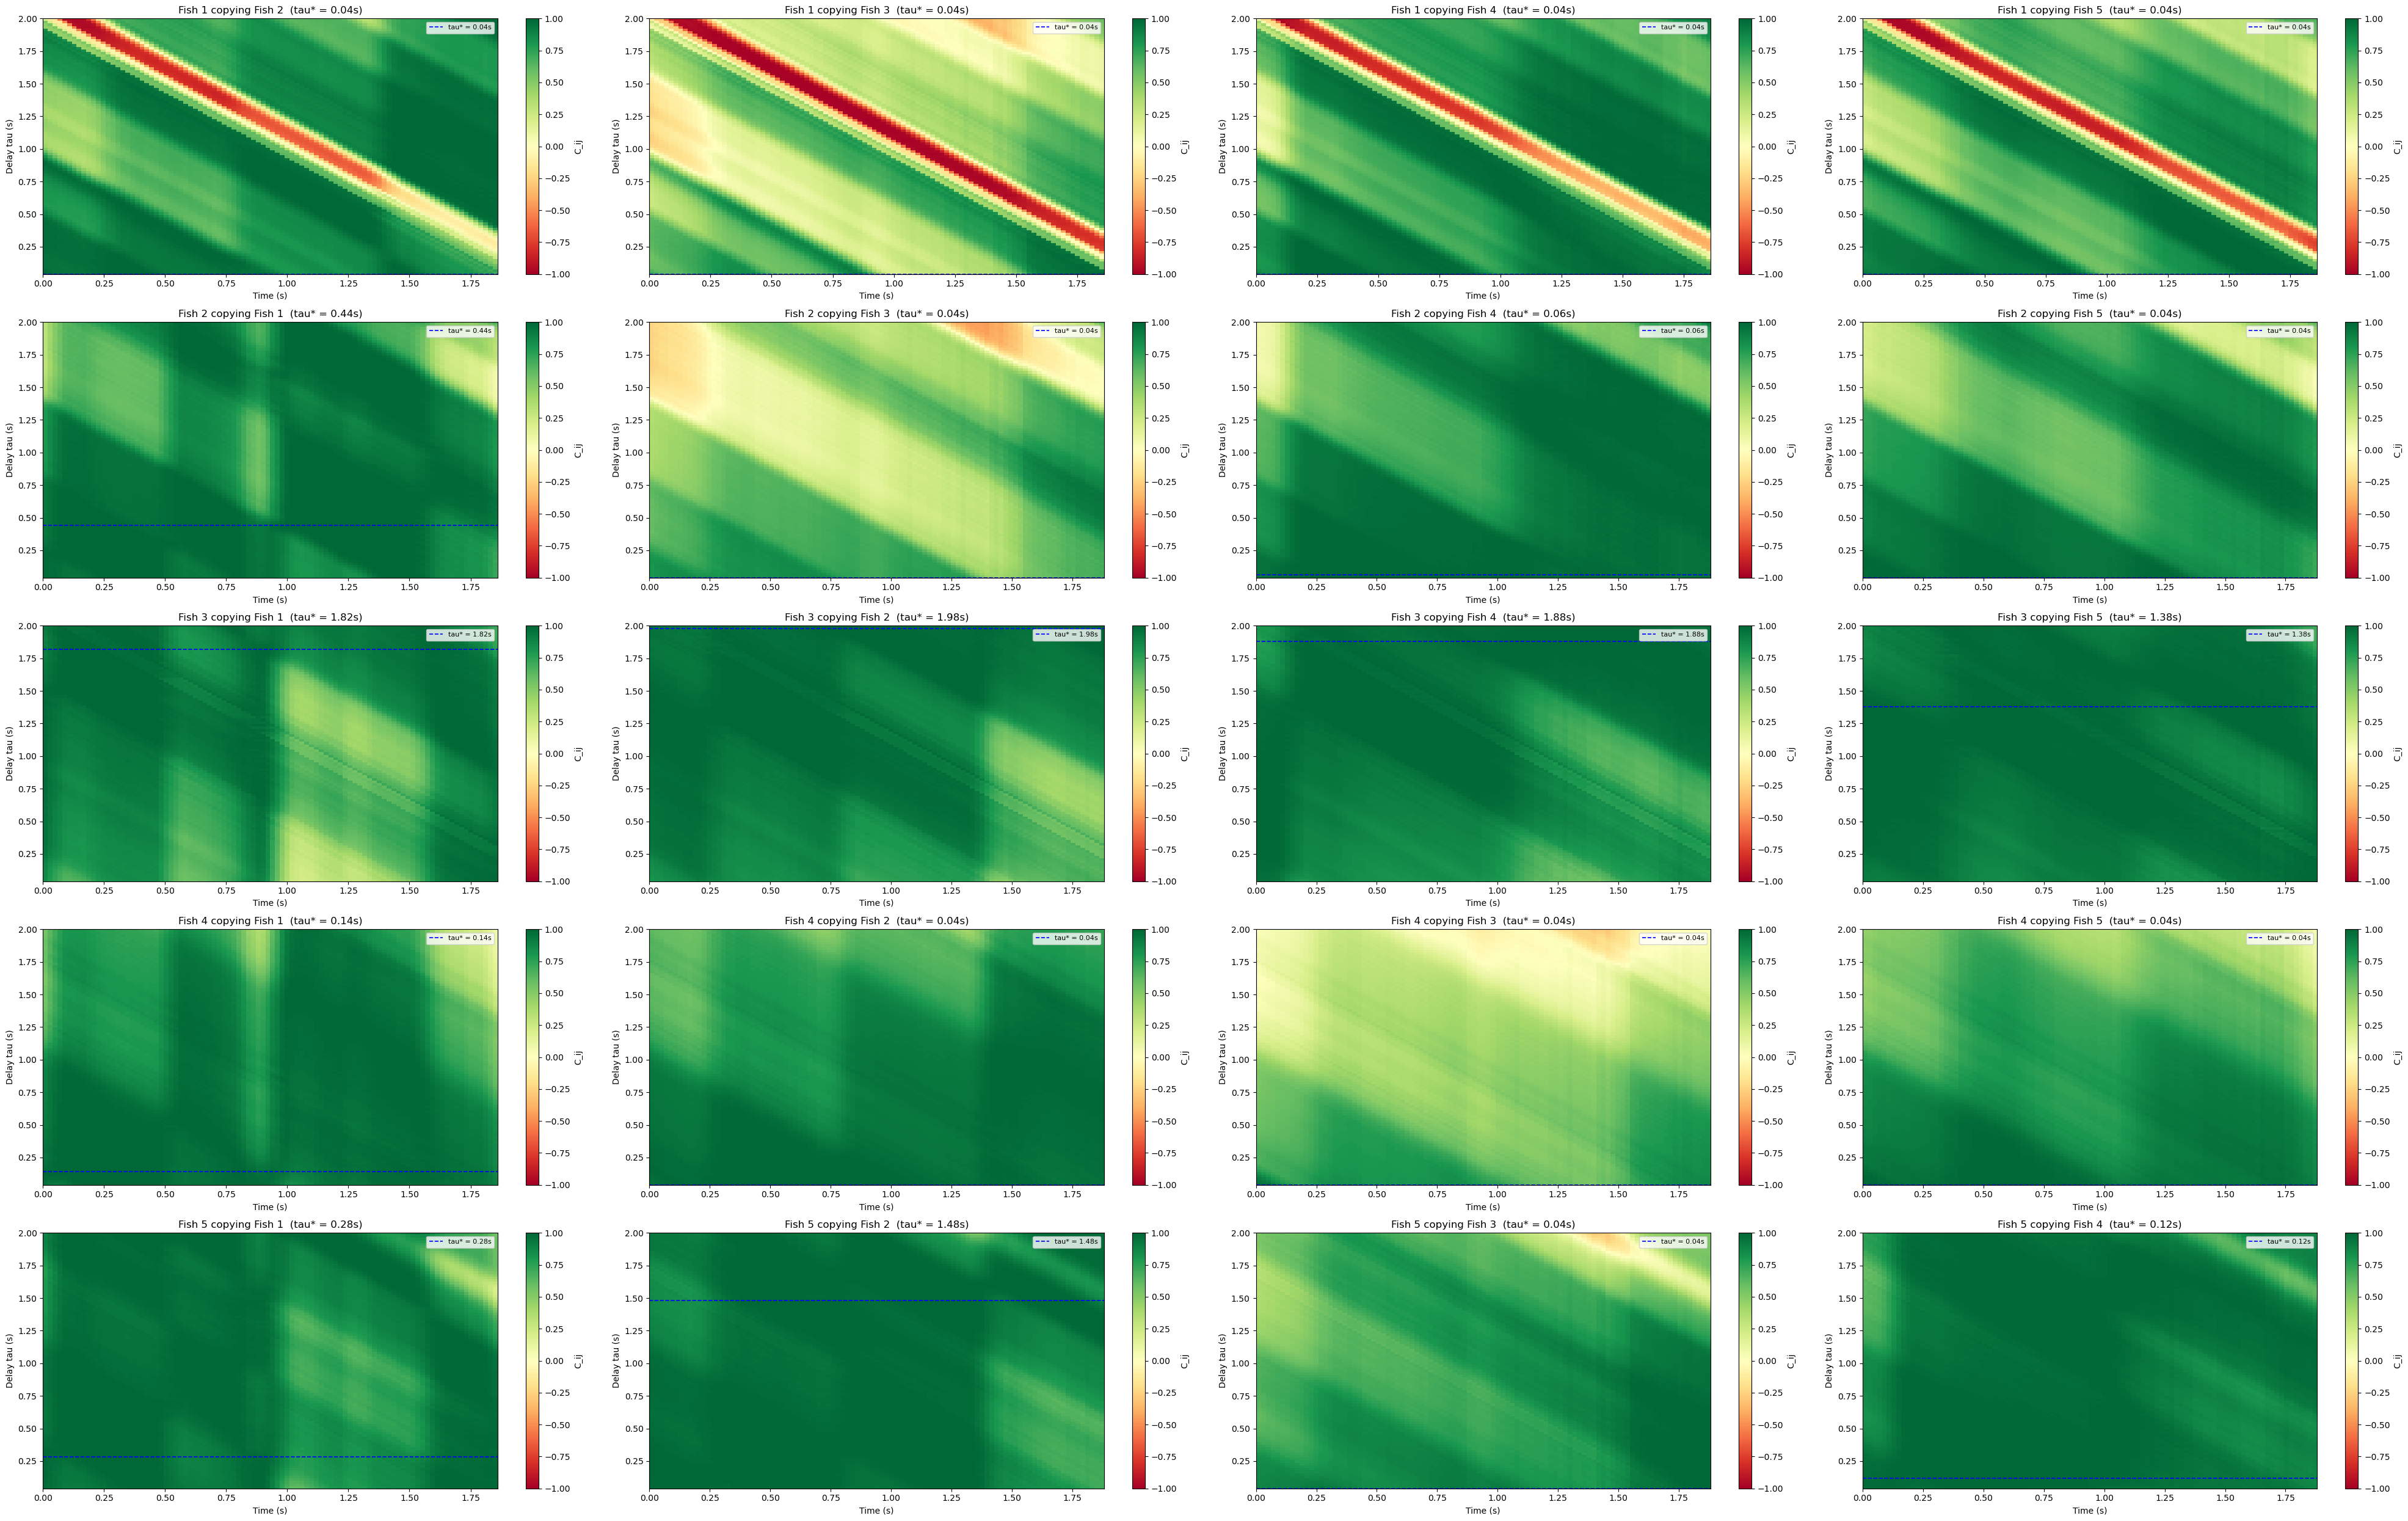

In [22]:
if __name__ == '__main__':
    from data_access import get_experement_paths, split_at_nans

    data_path  = get_experement_paths(group_size=5, limit=1)[0]
    data       = pd.read_csv(data_path)
    clean_data = split_at_nans(data)

    chunk = max(clean_data, key=len)
    chunk = chunk.reset_index(drop=True)

    # find a U-turn and zoom in
    x0    = chunk.iloc[:, 0].values
    y0    = chunk.iloc[:, 1].values
    turns = find_turning_points(x0, y0)
    print(f'turns found: {len(turns)}')

    # 200 frames around the 10th turn
    turn_frame = turns[30][0]
    window     = chunk.iloc[turn_frame - 100 : turn_frame + 100]

    vectors = get_unit_vectors(window)
    n_fish  = len(vectors)

    pairs = [(i, j) for i in range(n_fish) for j in range(n_fish) if i != j]
    ncols = 4
    nrows = int(np.ceil(len(pairs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 5 * nrows))
    axes_flat = axes.flatten()

    for idx, (i, j) in enumerate(pairs):
        C, taus_s = compute_Cij_matrix(vectors[i], vectors[j])
        plot_heatmap(C, taus_s, i, j, ax=axes_flat[idx])

    for ax in axes_flat[len(pairs):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


turns found: 132


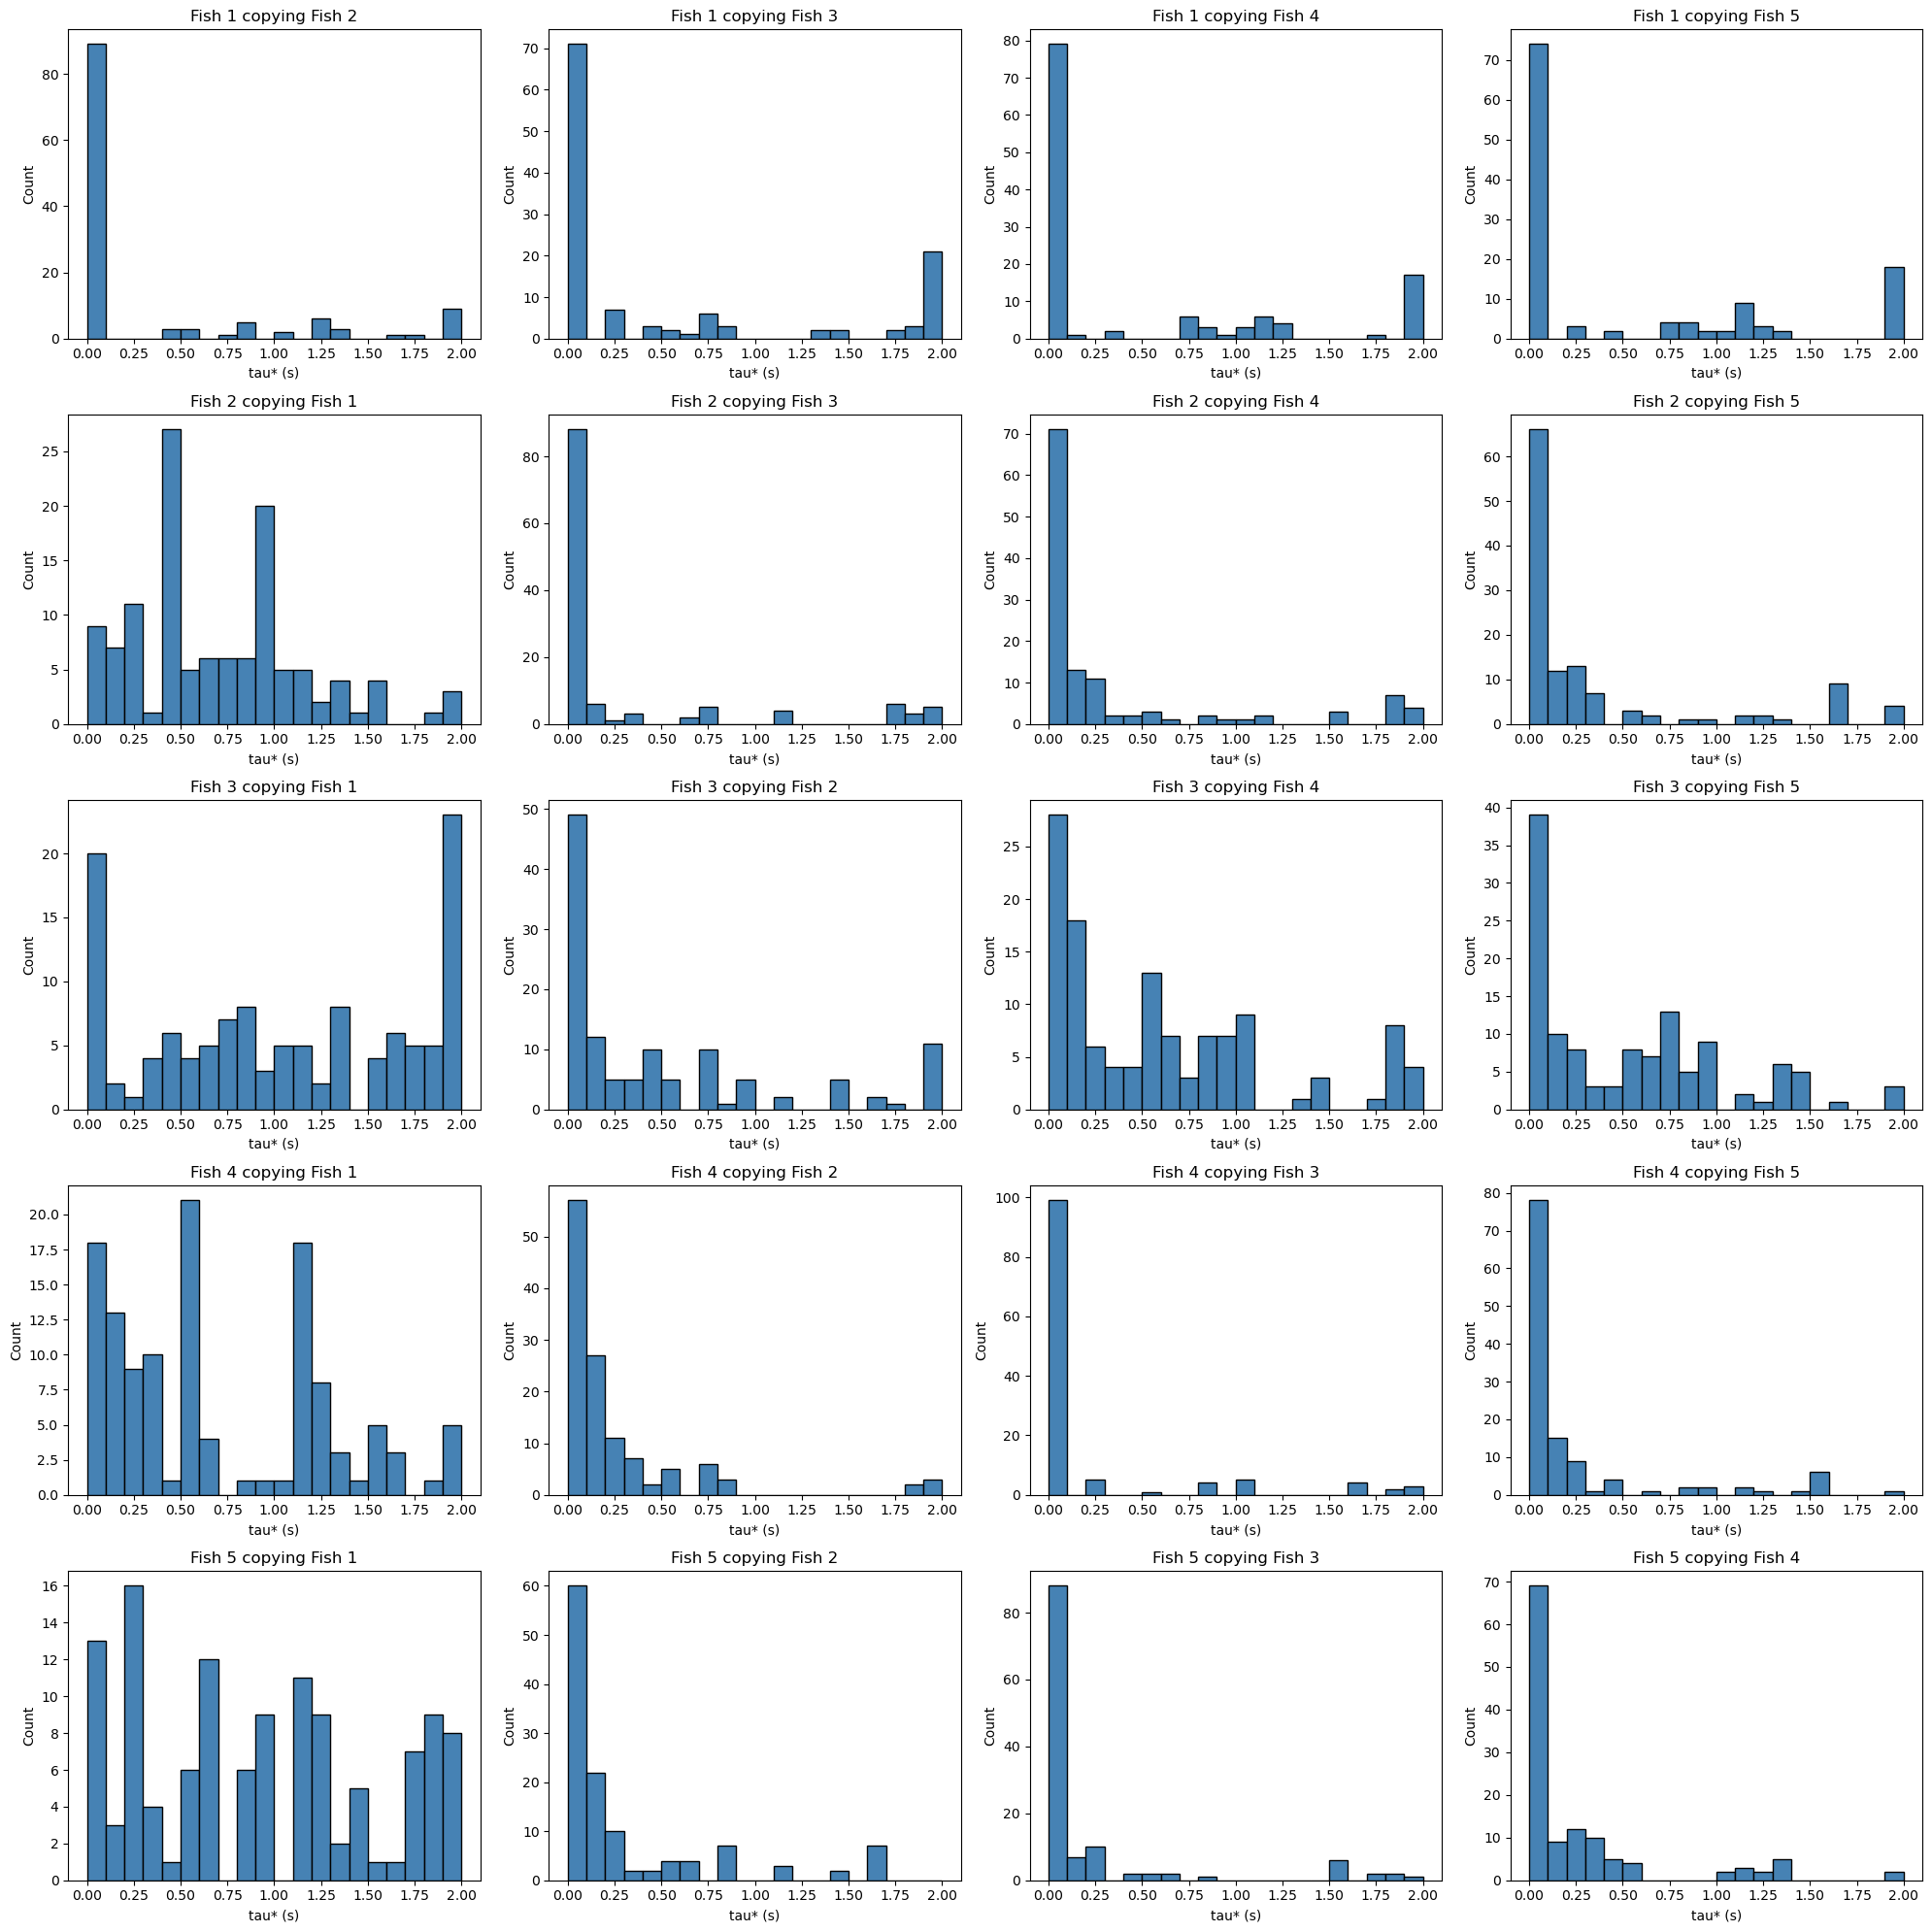

In [23]:
if __name__ == '__main__':
    from data_access import get_experement_paths, split_at_nans

    data_path  = get_experement_paths(group_size=5, limit=1)[0]
    data       = pd.read_csv(data_path)
    clean_data = split_at_nans(data)

    chunk = max(clean_data, key=len)
    chunk = chunk.reset_index(drop=True)

    x0    = chunk.iloc[:, 0].values
    y0    = chunk.iloc[:, 1].values
    turns = find_turning_points(x0, y0)
    print(f'turns found: {len(turns)}')

    # collect tau* for every pair across all turns
    all_taus = {(i, j): [] for i in range(5) for j in range(5) if i != j}

    for turn_start, _ in turns:
        if turn_start < 100 or turn_start + 100 > len(chunk):
            continue

        window  = chunk.iloc[turn_start - 100 : turn_start + 100]
        vectors = get_unit_vectors(window)

        for i in range(5):
            for j in range(5):
                if i == j:
                    continue
                C, taus_s = compute_Cij_matrix(vectors[i], vectors[j])
                if C.size == 0 or np.isnan(C).all():
                    continue
                best_tau = taus_s[int(np.argmax(np.nanmean(C, axis=1)))]
                all_taus[(i, j)].append(best_tau)

    # plot histogram of tau* for each pair
    pairs = list(all_taus.keys())
    ncols = 4
    nrows = int(np.ceil(len(pairs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = axes.flatten()

    for idx, (i, j) in enumerate(pairs):
        axes_flat[idx].hist(all_taus[(i, j)], bins=20, range=(0, 2),
                            color='steelblue', edgecolor='black')
        axes_flat[idx].set_title(f'Fish {i+1} copying Fish {j+1}')
        axes_flat[idx].set_xlabel('tau* (s)')
        axes_flat[idx].set_ylabel('Count')

    for ax in axes_flat[len(pairs):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


In [ ]:
# - Fish 1 copying Fish 2, 4 and 5 was strongly peaked at tau* = 0.04s, suggesting Fish 1 is a leader rather than a follower.
# - Fish 2 copying Fish 1 showed a broader distribution with a peak around 0.25s, indicating Fish 2 follows Fish 1 with a real delay.
# - Fish 3 copying Fish 1 and 2 showed broad flat distributions, suggesting Fish 3 does not consistently follow any individual.
# - Fish 4 copying Fish 3 and Fish 5 copying Fish 3 both showed very sharp peaks at tau* = 0.04s, indicating strong following behaviour.
# - The spike at the minimum delay across many pairs may reflect genuine near-instant copying or noise; the paper filters these out using a reaction time threshold.

turns found: 20830
first 5 turn frames: [np.int64(0), np.int64(1), np.int64(4), np.int64(5), np.int64(6)]
chunk length: 66873


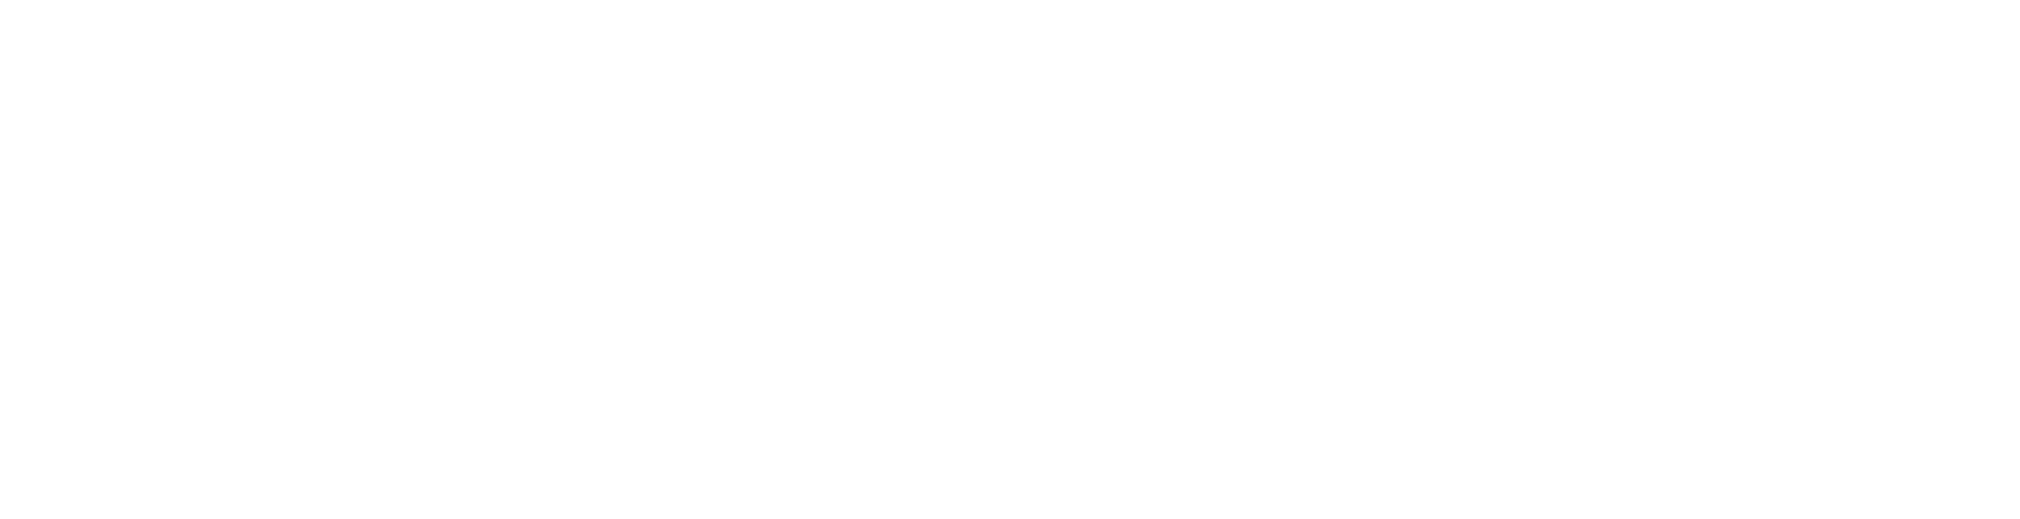

In [30]:
if __name__ == '__main__':
    from data_access import get_experement_paths, split_at_nans

    data_path  = get_experement_paths(group_size=2, limit=1)[0]
    data       = pd.read_csv(data_path)
    clean_data = split_at_nans(data)

    chunk = max(clean_data, key=len)
    chunk = chunk.reset_index(drop=True)

    x0    = chunk.iloc[:, 0].values
    y0    = chunk.iloc[:, 1].values
    turns = find_turning_points(x0, y0)

    turn_frame = turns[50][0]
    window     = chunk.iloc[turn_frame - 100 : turn_frame + 100]

    vectors = get_unit_vectors(window)
    n_fish  = len(vectors)

    pairs = [(i, j) for i in range(n_fish) for j in range(n_fish) if i != j]
    fig, axes = plt.subplots(1, len(pairs), figsize=(10 * len(pairs), 5))

    for ax, (i, j) in zip(axes, pairs):
        C, taus_s = compute_Cij_matrix(vectors[i], vectors[j])
        if C.size == 0 or np.isnan(C).all():
            ax.set_visible(False)
            continue
        plot_heatmap(C, taus_s, i, j, ax=ax)

    print(f'turns found: {len(turns)}')
    print(f'first 5 turn frames: {[t[0] for t in turns[:5]]}')
    print(f'chunk length: {len(chunk)}')
    plt.tight_layout()
    plt.show()

turns found: 20830


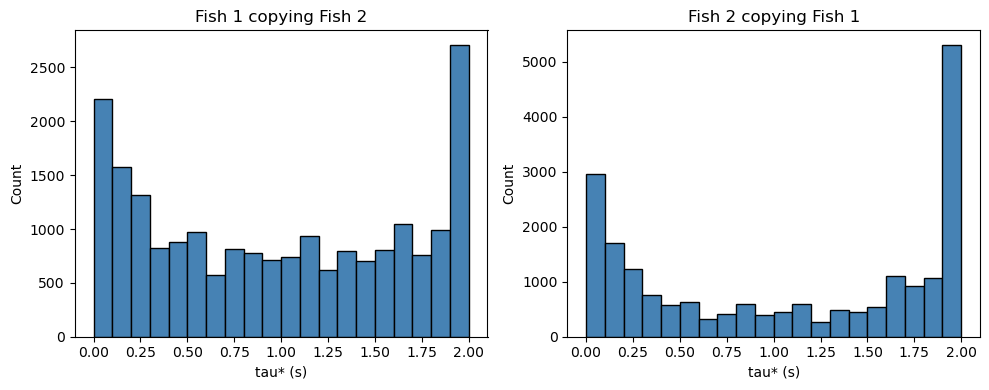

In [25]:
if __name__ == '__main__':
    from data_access import get_experement_paths, split_at_nans

    data_path  = get_experement_paths(group_size=2, limit=1)[0]
    data       = pd.read_csv(data_path)
    clean_data = split_at_nans(data)

    chunk = max(clean_data, key=len)
    chunk = chunk.reset_index(drop=True)

    x0    = chunk.iloc[:, 0].values
    y0    = chunk.iloc[:, 1].values
    turns = find_turning_points(x0, y0)
    print(f'turns found: {len(turns)}')

    all_taus = {(i, j): [] for i in range(2) for j in range(2) if i != j}

    for turn_start, _ in turns:
        if turn_start < 100 or turn_start + 100 > len(chunk):
            continue

        window  = chunk.iloc[turn_start - 100 : turn_start + 100]
        vectors = get_unit_vectors(window)

        for i in range(2):
            for j in range(2):
                if i == j:
                    continue
                C, taus_s = compute_Cij_matrix(vectors[i], vectors[j])
                if C.size == 0 or np.isnan(C).all():
                    continue
                best_tau = taus_s[int(np.argmax(np.nanmean(C, axis=1)))]
                all_taus[(i, j)].append(best_tau)

    pairs = list(all_taus.keys())
    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))

    for idx, (i, j) in enumerate(pairs):
        axes[idx].hist(all_taus[(i, j)], bins=20, range=(0, 2),
                       color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Fish {i+1} copying Fish {j+1}')
        axes[idx].set_xlabel('tau* (s)')
        axes[idx].set_ylabel('Count')

    plt.tight_layout()
    plt.show()